# Final figures

This notebook consolidates results across datasets and sensitive attributes.

- load cached experiment bundles
- concatenate summaries
- build combined tables
- generate final cross-dataset figures


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from fair_bandits.config import build_config
from fair_bandits.io import experiment_bundle_exists, load_experiment_bundle
from fair_bandits.experiments import summarize_over_seeds, compare_methods
from fair_bandits.plots import (
    plot_average_reward_over_time,
    plot_dp_gap_over_time,
    plot_benchmark_bars,
)


### Load config

In [2]:
CFG = build_config("full")   # switch to "full" when ready for final exports

REQUESTED_CONDITIONS = [
    {"dataset": "COMPAS", "sensitive": "sex", "preprocessing": "reweigh_group_label"},
    {"dataset": "COMPAS", "sensitive": "race_binary", "preprocessing": "reweigh_group_label"},
    {"dataset": "ADULT", "sensitive": "sex", "preprocessing": "reweigh_group_label"},
    {"dataset": "ADULT", "sensitive": "race", "preprocessing": "reweigh_group_label"},
]

BENCHMARK_METRIC = "EO_gap"   # change here if you want another bar figure metric

CFG


ExperimentConfig(run_mode='full', seed0=42, cache_dir=WindowsPath('data_cache'), results_dir=WindowsPath('results/full'), T_group_bandit=50000, T_contextual=30000, n_seeds=50, delta_fair=0.05, alpha_linucb=1.5, lambda_ridge=1.0, dp_tau=0.02, dp_lambda=2.0, beta_smooth=1.0, min_group_count=20, compas_hash_features=512, n_bootstrap=1000)

### Load cached experiment

In [3]:
def build_run_dir(cfg, dataset: str, sensitive: str, preprocessing: str) -> Path:
    return (
        cfg.results_dir
        / dataset.lower()
        / f"sensitive_{sensitive}"
        / preprocessing
    )


bundles = {}
missing = []

for cond in REQUESTED_CONDITIONS:
    run_dir = build_run_dir(
        CFG,
        cond["dataset"],
        cond["sensitive"],
        cond["preprocessing"],
    )
    key = (cond["dataset"], cond["sensitive"], cond["preprocessing"])

    if experiment_bundle_exists(run_dir):
        bundles[key] = load_experiment_bundle(run_dir)
        print("Loaded:", run_dir)
    else:
        missing.append(run_dir)

if missing:
    print("\nMissing experiment bundles:")
    for p in missing:
        print(" -", p)

if not bundles:
    raise ValueError(
        "No experiment bundles were found. Run compas_experiments.ipynb and "
        "adult_experiments.ipynb first, then rerun this notebook."
    )


Loaded: results\full\compas\sensitive_sex\reweigh_group_label
Loaded: results\full\compas\sensitive_race_binary\reweigh_group_label
Loaded: results\full\adult\sensitive_sex\reweigh_group_label
Loaded: results\full\adult\sensitive_race\reweigh_group_label


### Aggregate results

In [4]:
seed_summary_all = pd.concat(
    [bundle.seed_summary for bundle in bundles.values()],
    ignore_index=True,
)

logs_all = pd.concat(
    [bundle.logs for bundle in bundles.values()],
    ignore_index=True,
)

agg_summary = summarize_over_seeds(
    seed_summary_all,
    group_cols=["dataset", "sensitive", "preprocessing", "policy"],
)

print("Available values:")
for col in ["dataset", "sensitive", "preprocessing", "policy"]:
    if col in seed_summary_all.columns:
        print(f"- {col}: {sorted(seed_summary_all[col].astype(str).unique().tolist())}")

available_conditions_df = (
    seed_summary_all[["dataset", "sensitive", "preprocessing"]]
    .drop_duplicates()
    .sort_values(["dataset", "sensitive", "preprocessing"])
    .reset_index(drop=True)
)

display(available_conditions_df)
display(agg_summary.sort_values(["dataset", "sensitive", "policy"]).reset_index(drop=True))

PLOT_CONDITIONS = []
for cond in REQUESTED_CONDITIONS:
    mask = pd.Series(True, index=seed_summary_all.index)
    for k, v in cond.items():
        mask &= seed_summary_all[k].astype(str) == str(v)
    if mask.any():
        PLOT_CONDITIONS.append(cond)
    else:
        print(f"Skipping missing condition: {cond}")

if not PLOT_CONDITIONS:
    PLOT_CONDITIONS = available_conditions_df.to_dict(orient="records")

print("\nConditions that will be used for figures:")
display(pd.DataFrame(PLOT_CONDITIONS))


Available values:
- dataset: ['ADULT', 'COMPAS']
- sensitive: ['race', 'race_binary', 'sex']
- preprocessing: ['reweigh_group_label']
- policy: ['GroupAwareDPLinUCB', 'LinUCB']


,dataset,sensitive,preprocessing
0,ADULT,race,reweigh_group_label
1,ADULT,sex,reweigh_group_label
2,COMPAS,race_binary,reweigh_group_label
3,COMPAS,sex,reweigh_group_label


,dataset,sensitive,preprocessing,policy,n_seeds,accuracy_mean,accuracy_low,accuracy_high,DP_gap_mean,DP_gap_low,...,final_avg_reward_high,final_rolling_reward_mean,final_rolling_reward_low,final_rolling_reward_high,final_dp_gap_mean,final_dp_gap_low,final_dp_gap_high,final_cum_regret_mean,final_cum_regret_low,final_cum_regret_high
0,ADULT,race,reweigh_group_label,GroupAwareDPLinUCB,50,0.832672,0.819304,0.838762,0.052977,0.041591,...,0.838762,0.8344,0.7200,0.9155,0.052977,0.041591,0.062452,5019.84,4837.150,5420.875
1,ADULT,race,reweigh_group_label,LinUCB,50,0.831949,0.821955,0.838302,0.079846,0.057359,...,0.838302,0.8324,0.7200,0.9155,0.079846,0.057359,0.100272,5041.54,4850.950,5341.350
2,ADULT,sex,reweigh_group_label,GroupAwareDPLinUCB,50,0.813931,0.806712,0.818526,0.047533,0.035654,...,0.818526,0.8244,0.7045,0.9200,0.047533,0.035654,0.066088,5582.08,5444.225,5798.650
3,ADULT,sex,reweigh_group_label,LinUCB,50,0.813709,0.805419,0.818906,0.058467,0.041017,...,0.818906,0.8232,0.7135,0.9155,0.058467,0.041017,0.075926,5588.72,5432.825,5837.425
4,COMPAS,race_binary,reweigh_group_label,GroupAwareDPLinUCB,50,0.637356,0.583331,0.661488,0.026810,0.002700,...,0.661488,0.6488,0.4845,0.7955,0.026810,0.002700,0.062182,10879.32,10155.375,12500.075
5,COMPAS,race_binary,reweigh_group_label,LinUCB,50,0.639729,0.586658,0.661306,0.040923,0.001242,...,0.661306,0.6440,0.5400,0.7600,0.040923,0.001242,0.117713,10808.12,10160.825,12400.250
6,COMPAS,sex,reweigh_group_label,GroupAwareDPLinUCB,50,0.630315,0.543284,0.664666,0.049682,0.009031,...,0.664666,0.6344,0.4445,0.8000,0.049682,0.009031,0.065119,11090.56,10060.025,13701.475
7,COMPAS,sex,reweigh_group_label,LinUCB,50,0.629954,0.543179,0.665003,0.075677,0.021631,...,0.665003,0.6304,0.4400,0.7910,0.075677,0.021631,0.106554,11101.38,10049.925,13704.625



Conditions that will be used for figures:


,dataset,sensitive,preprocessing
0,COMPAS,sex,reweigh_group_label
1,COMPAS,race_binary,reweigh_group_label
2,ADULT,sex,reweigh_group_label
3,ADULT,race,reweigh_group_label


### Build final table

In [5]:
table_cols = [
    "dataset",
    "sensitive",
    "preprocessing",
    "policy",
    "accuracy_mean", "accuracy_low", "accuracy_high",
    "DP_gap_mean", "DP_gap_low", "DP_gap_high",
    "EO_gap_mean", "EO_gap_low", "EO_gap_high",
    "PPV_gap_mean", "PPV_gap_low", "PPV_gap_high",
    "CumulativeRegret_mean", "CumulativeRegret_low", "CumulativeRegret_high",
]

final_table = (
    agg_summary[table_cols]
    .sort_values(["dataset", "sensitive", "preprocessing", "policy"])
    .reset_index(drop=True)
)

display(final_table)


,dataset,sensitive,preprocessing,policy,accuracy_mean,accuracy_low,accuracy_high,DP_gap_mean,DP_gap_low,DP_gap_high,EO_gap_mean,EO_gap_low,EO_gap_high,PPV_gap_mean,PPV_gap_low,PPV_gap_high,CumulativeRegret_mean,CumulativeRegret_low,CumulativeRegret_high
0,ADULT,race,reweigh_group_label,GroupAwareDPLinUCB,0.832672,0.819304,0.838762,0.052977,0.041591,0.062452,0.124015,0.103412,0.145752,0.097594,0.073174,0.114800,5019.84,4837.150,5420.875
1,ADULT,race,reweigh_group_label,LinUCB,0.831949,0.821955,0.838302,0.079846,0.057359,0.100272,0.145176,0.120478,0.169447,0.107504,0.081456,0.127868,5041.54,4850.950,5341.350
2,ADULT,sex,reweigh_group_label,GroupAwareDPLinUCB,0.813931,0.806712,0.818526,0.047533,0.035654,0.066088,0.117179,0.102109,0.139160,0.092170,0.077298,0.104866,5582.08,5444.225,5798.650
3,ADULT,sex,reweigh_group_label,LinUCB,0.813709,0.805419,0.818906,0.058467,0.041017,0.075926,0.127979,0.110335,0.140154,0.098153,0.083044,0.108058,5588.72,5432.825,5837.425
4,COMPAS,race_binary,reweigh_group_label,GroupAwareDPLinUCB,0.637356,0.583331,0.661488,0.026810,0.002700,0.062182,0.052339,0.013504,0.082549,0.024610,0.002536,0.059504,10879.32,10155.375,12500.075
5,COMPAS,race_binary,reweigh_group_label,LinUCB,0.639729,0.586658,0.661306,0.040923,0.001242,0.117713,0.066781,0.019202,0.123035,0.025652,0.001474,0.066345,10808.12,10160.825,12400.250
6,COMPAS,sex,reweigh_group_label,GroupAwareDPLinUCB,0.630315,0.543284,0.664666,0.049682,0.009031,0.065119,0.064065,0.031145,0.104578,0.022693,0.002557,0.052321,11090.56,10060.025,13701.475
7,COMPAS,sex,reweigh_group_label,LinUCB,0.629954,0.543179,0.665003,0.075677,0.021631,0.106554,0.090517,0.038309,0.124610,0.028829,0.008208,0.055122,11101.38,10049.925,13704.625


### Generate figures

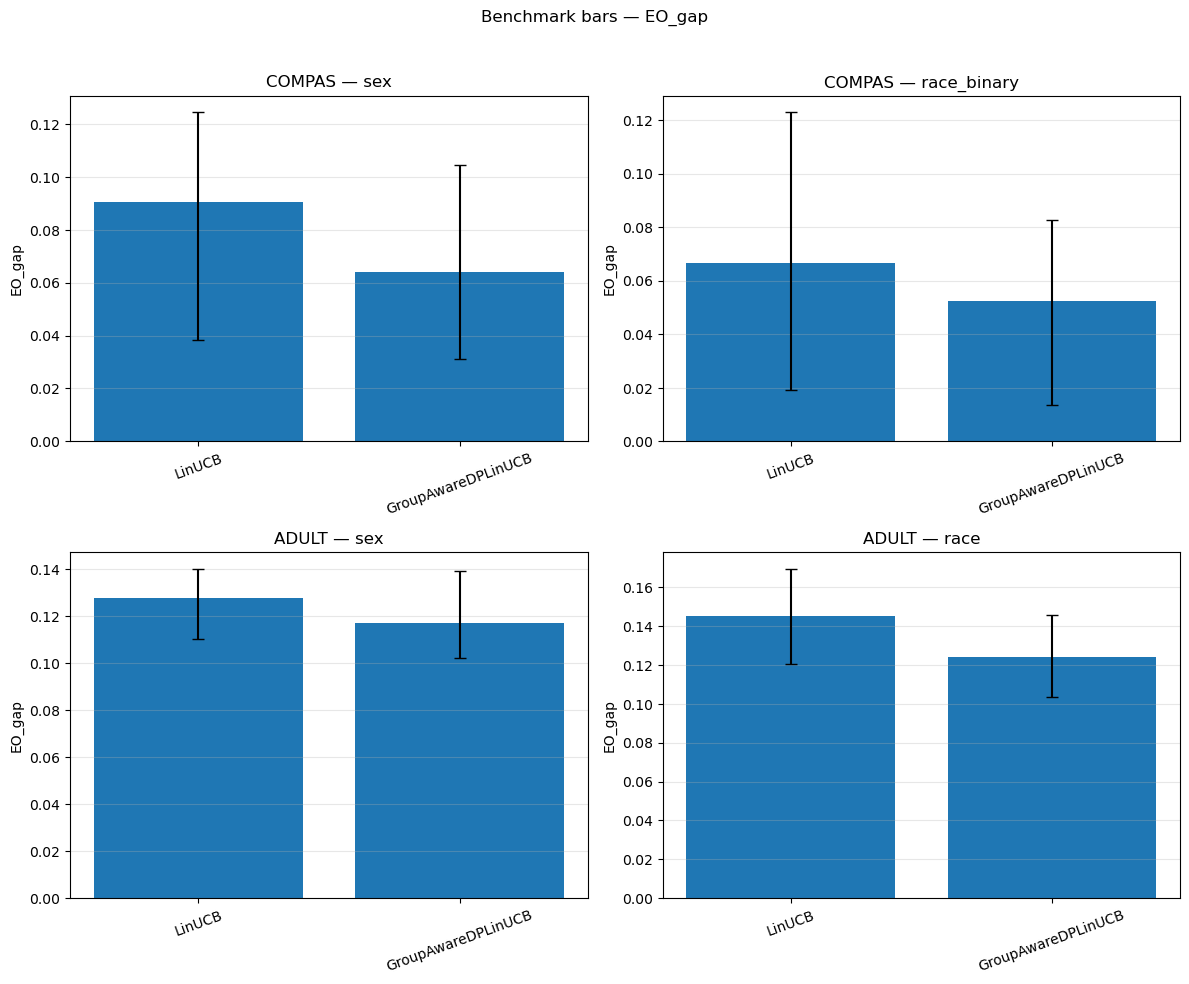

In [6]:
import math


n_panels = len(PLOT_CONDITIONS)
ncols = 2
nrows = math.ceil(n_panels / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.8 * nrows))
if isinstance(axes, plt.Axes):
    axes = [axes]
else:
    axes = list(axes.ravel())

for ax, cond in zip(axes, PLOT_CONDITIONS):
    plot_benchmark_bars(
        seed_summary_all,
        metric=BENCHMARK_METRIC,
        filters=cond,
        policy_order=["LinUCB", "GroupAwareDPLinUCB"],
        ax=ax,
        title=f'{cond["dataset"]} — {cond["sensitive"]}',
        rotate_xticks=20,
    )

for ax in axes[len(PLOT_CONDITIONS):]:
    ax.axis("off")

plt.suptitle(f"Benchmark bars — {BENCHMARK_METRIC}", y=1.02)
plt.tight_layout()
plt.show()


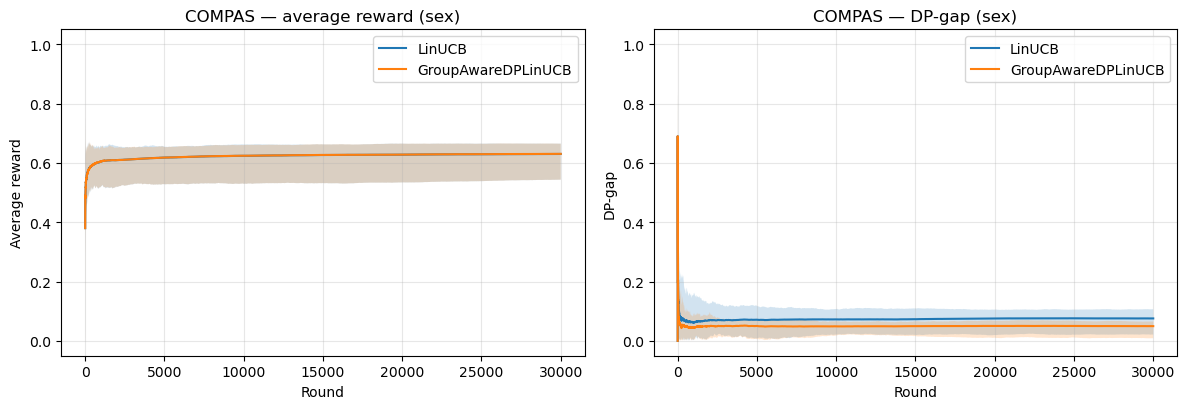

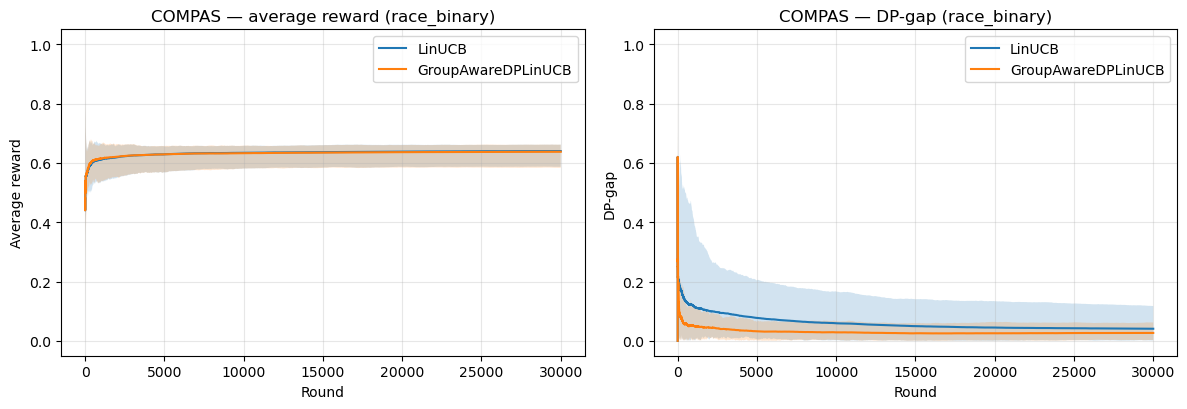

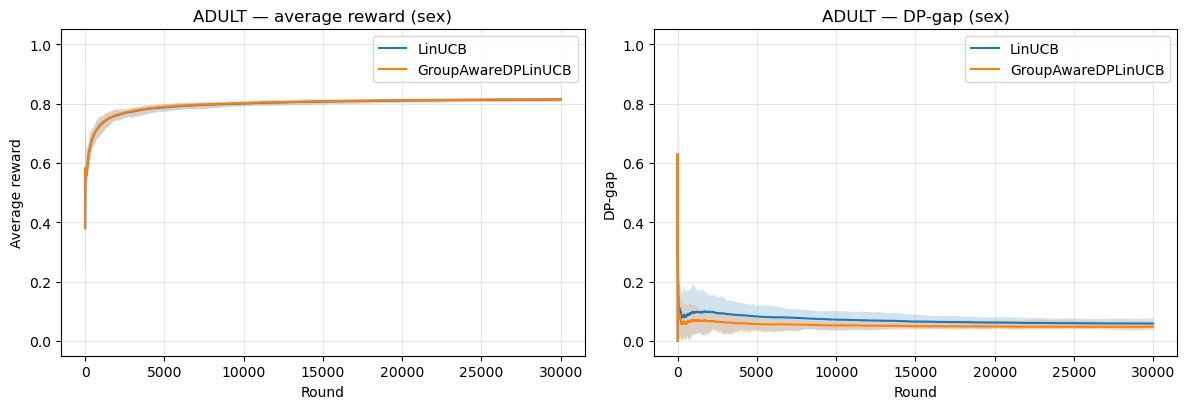

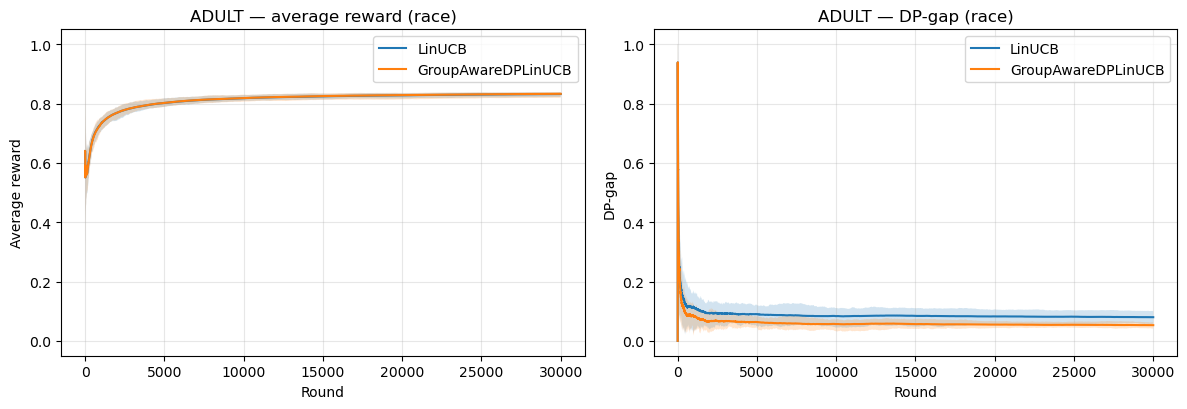

In [7]:
for cond in PLOT_CONDITIONS:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

    plot_average_reward_over_time(
        logs_all,
        filters=cond,
        policy_order=["LinUCB", "GroupAwareDPLinUCB"],
        ax=axes[0],
        title=f'{cond["dataset"]} — average reward ({cond["sensitive"]})',
    )

    plot_dp_gap_over_time(
        logs_all,
        filters=cond,
        policy_order=["LinUCB", "GroupAwareDPLinUCB"],
        ax=axes[1],
        title=f'{cond["dataset"]} — DP-gap ({cond["sensitive"]})',
    )

    plt.tight_layout()
    plt.show()


### Statistical tests

In [8]:
friedman_rows = []
wilcoxon_rows = []

for cond in PLOT_CONDITIONS:
    subset = seed_summary_all.copy()
    for col, val in cond.items():
        subset = subset[subset[col].astype(str) == str(val)]

    if subset.empty:
        print(f"Skipping statistics for empty subset: {cond}")
        continue

    # With only two policies, Friedman is generally not appropriate.
    # compare_methods will still return pairwise Wilcoxon results.
    for metric_name, lower_is_better in [
        ("EO_gap", True),
        ("DP_gap", True),
        ("CumulativeRegret", True),
        ("accuracy", False),
    ]:
        friedman_df, wilcoxon_df = compare_methods(
            subset,
            value_col=metric_name,
            method_col="policy",
            seed_col="seed",
            group_cols=["dataset", "sensitive", "preprocessing"],
            lower_is_better=lower_is_better,
        )
        if not friedman_df.empty:
            friedman_rows.append(friedman_df)
        if not wilcoxon_df.empty:
            wilcoxon_rows.append(wilcoxon_df)

friedman_all = pd.concat(friedman_rows, ignore_index=True) if friedman_rows else pd.DataFrame()
wilcoxon_all = pd.concat(wilcoxon_rows, ignore_index=True) if wilcoxon_rows else pd.DataFrame()

display(friedman_all)
display(wilcoxon_all)


""


,dataset,sensitive,preprocessing,value_col,method_a,method_b,n_pairs,mean_a,mean_b,mean_diff_a_minus_b,statistic,p_raw,winner,p_holm
0,COMPAS,sex,reweigh_group_label,EO_gap,GroupAwareDPLinUCB,LinUCB,50,0.064065,0.090517,-0.026452,10.0,2.056946e-09,GroupAwareDPLinUCB,2.056946e-09
1,COMPAS,sex,reweigh_group_label,DP_gap,GroupAwareDPLinUCB,LinUCB,50,0.049682,0.075677,-0.025995,5.0,1.512920e-09,GroupAwareDPLinUCB,1.512920e-09
2,COMPAS,sex,reweigh_group_label,CumulativeRegret,GroupAwareDPLinUCB,LinUCB,50,11090.560000,11101.380000,-10.820000,487.0,4.151261e-01,GroupAwareDPLinUCB,4.151261e-01
3,COMPAS,sex,reweigh_group_label,accuracy,GroupAwareDPLinUCB,LinUCB,50,0.630315,0.629954,0.000361,487.0,4.151391e-01,GroupAwareDPLinUCB,4.151391e-01
4,COMPAS,race_binary,reweigh_group_label,EO_gap,GroupAwareDPLinUCB,LinUCB,50,0.052339,0.066781,-0.014442,287.0,5.086666e-04,GroupAwareDPLinUCB,5.086666e-04
5,COMPAS,race_binary,reweigh_group_label,DP_gap,GroupAwareDPLinUCB,LinUCB,50,0.026810,0.040923,-0.014113,333.0,2.799361e-03,GroupAwareDPLinUCB,2.799361e-03
6,COMPAS,race_binary,reweigh_group_label,CumulativeRegret,GroupAwareDPLinUCB,LinUCB,50,10879.320000,10808.120000,71.200000,561.0,4.601679e-01,LinUCB,4.601679e-01
7,COMPAS,race_binary,reweigh_group_label,accuracy,GroupAwareDPLinUCB,LinUCB,50,0.637356,0.639729,-0.002373,560.5,4.572593e-01,LinUCB,4.572593e-01
8,ADULT,sex,reweigh_group_label,EO_gap,GroupAwareDPLinUCB,LinUCB,50,0.117179,0.127979,-0.010800,51.0,6.337864e-11,GroupAwareDPLinUCB,6.337864e-11
9,ADULT,sex,reweigh_group_label,DP_gap,GroupAwareDPLinUCB,LinUCB,50,0.047533,0.058467,-0.010934,33.0,5.707435e-12,GroupAwareDPLinUCB,5.707435e-12


### Export tables

In [9]:
final_out = CFG.results_dir / "final_figures"
final_out.mkdir(parents=True, exist_ok=True)

final_table.to_csv(final_out / "final_table.csv", index=False)
friedman_all.to_csv(final_out / "final_friedman_tests.csv", index=False)
wilcoxon_all.to_csv(final_out / "final_wilcoxon_tests.csv", index=False)

print("Exported final tables to:", final_out)


Exported final tables to: results\full\final_figures
